This notebook is intended to be the one where I gather the results for the GETLM.

In [23]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
# # I will also be defining a L2 norm function
# def L2_norm(result, reality):
#     L2 = sum(abs(result - reality))/sum(abs(reality))
#     return L2

def L2_norm(result, reality):
    # Using PyTorch's built-in L2 norm (p=2)
    L2 = torch.norm(result - reality, p=2) / torch.norm(reality, p=2)
    return L2

In [25]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [26]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 9669.47it/s]


In [ ]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = [0]
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_CN = 2 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = 8)


This may need to be modified to perturb the past state variable

In [28]:
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE = [[0],[-3,-2,-1,0,1,2,3]]


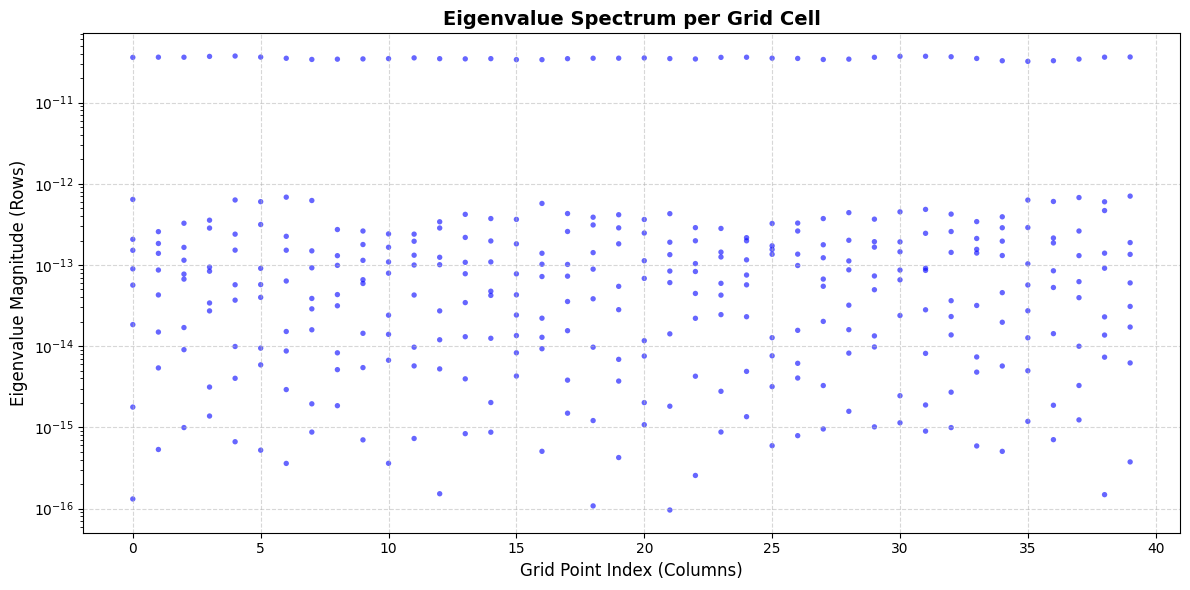

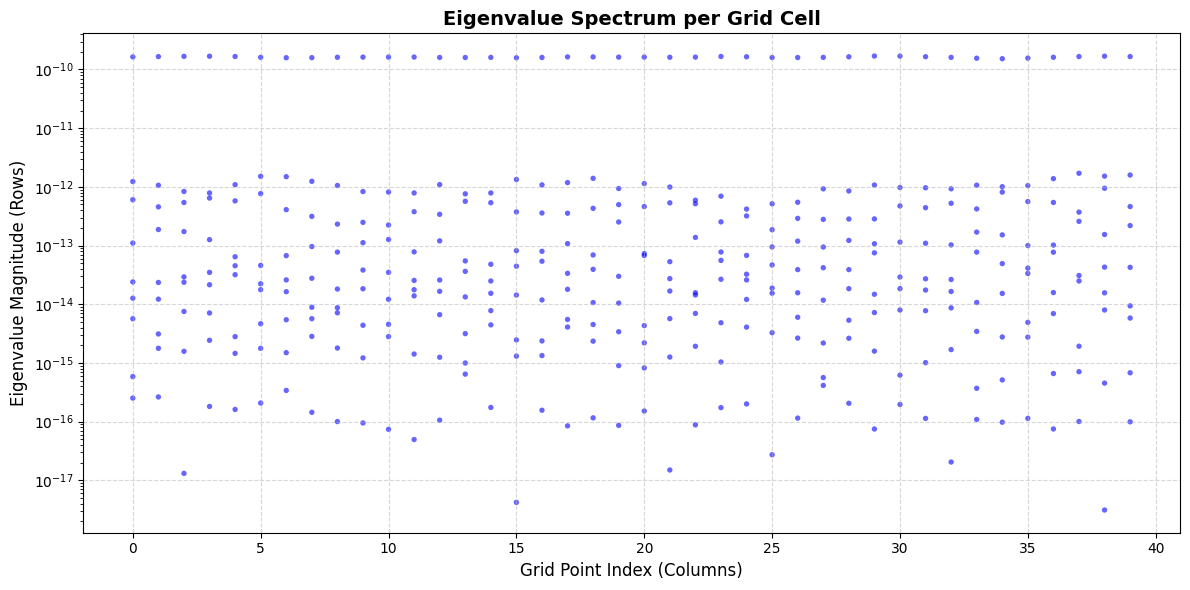

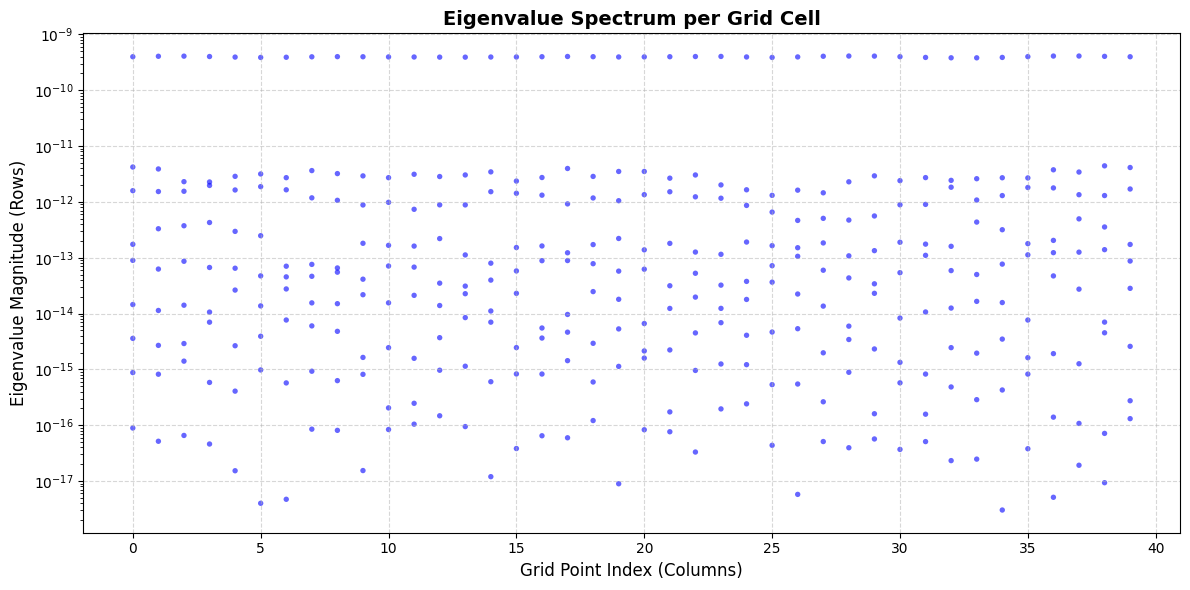

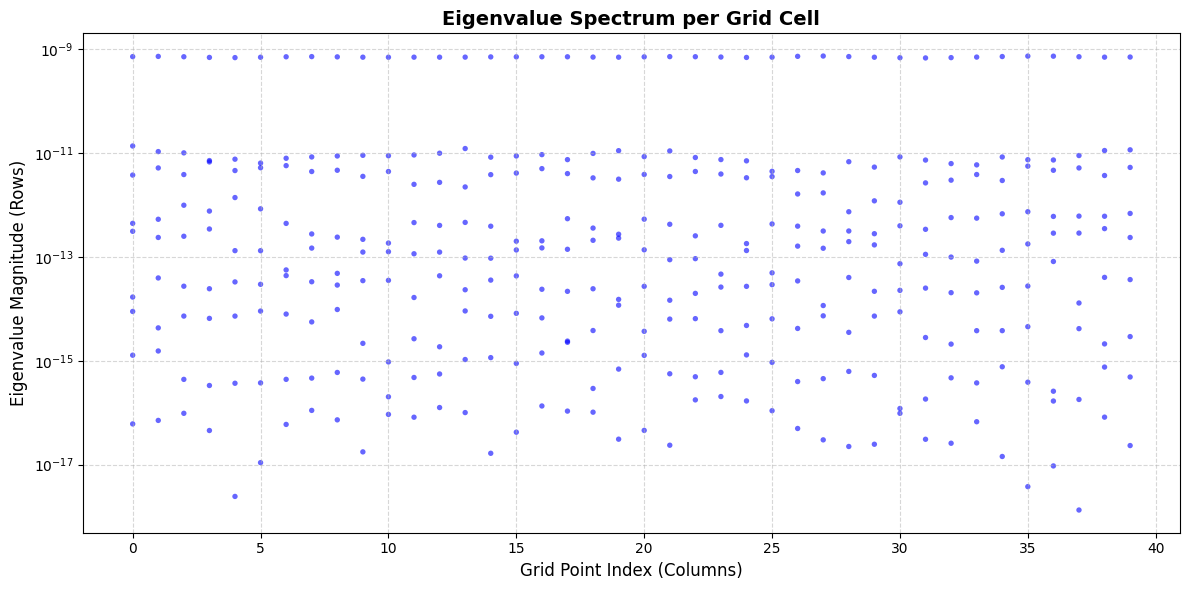

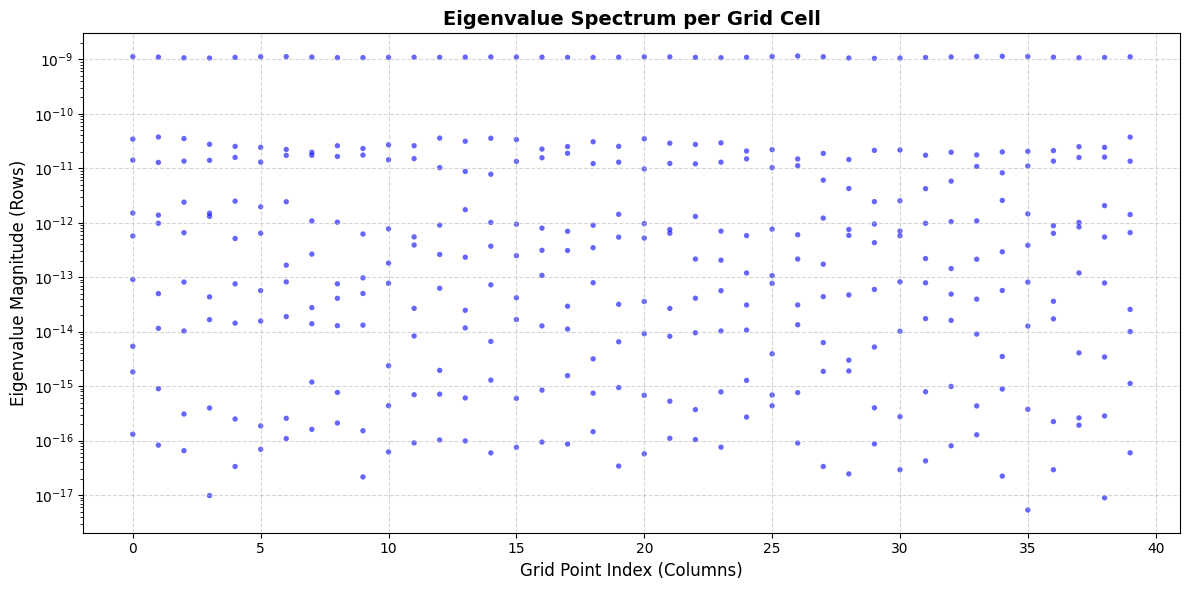

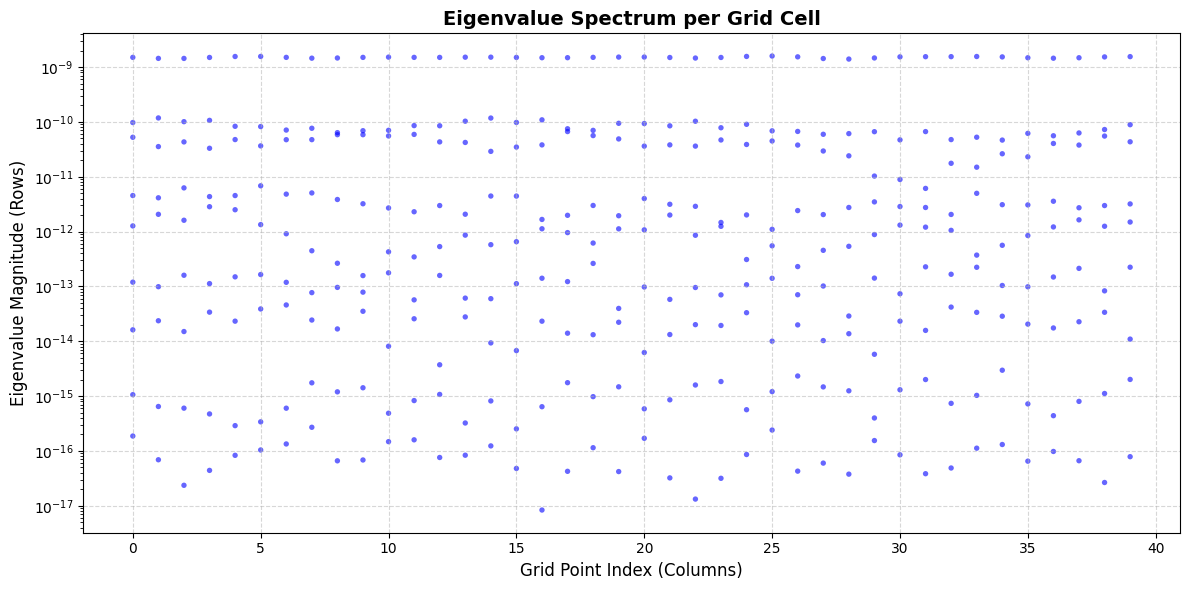

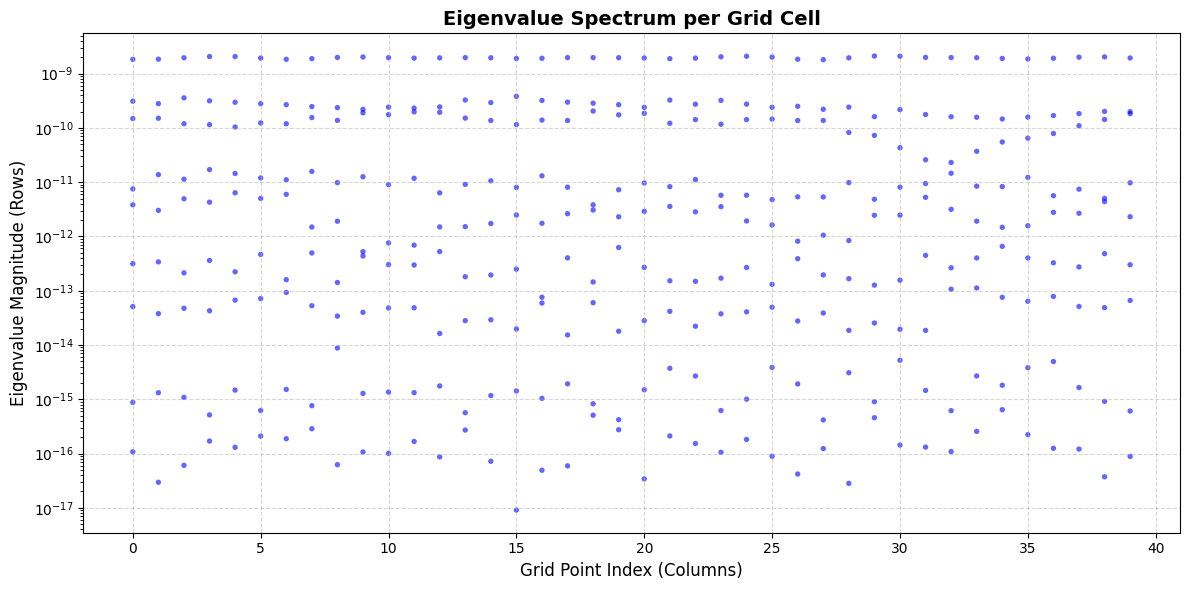

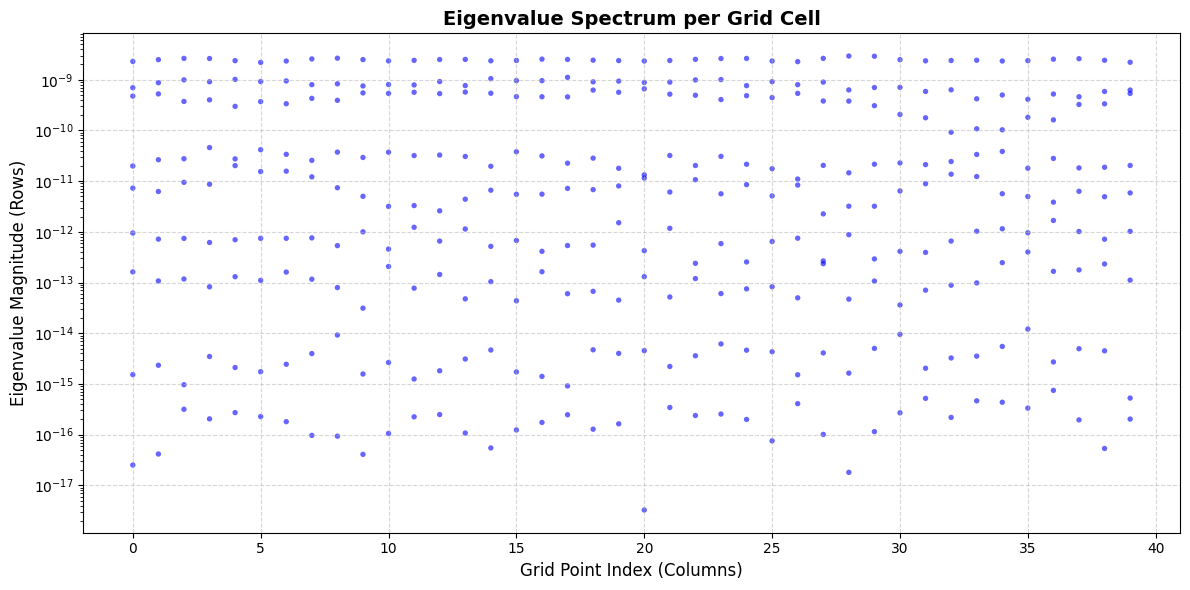

In [29]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 2 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    LETLMS.append(M_tilde)


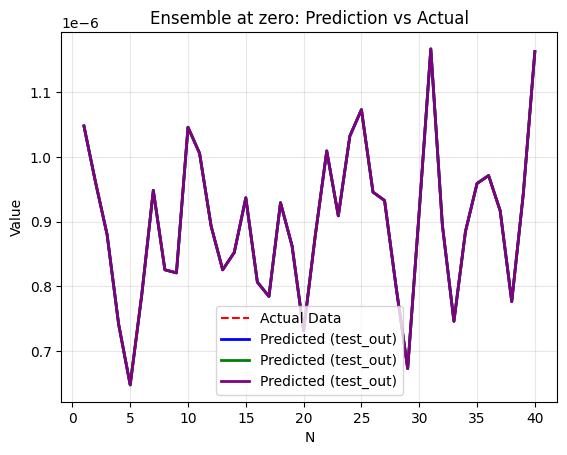

IETLM norm: tensor(0.0345)
LETLM norm: tensor(0.0257)
GETLM norm: tensor(0.0165)


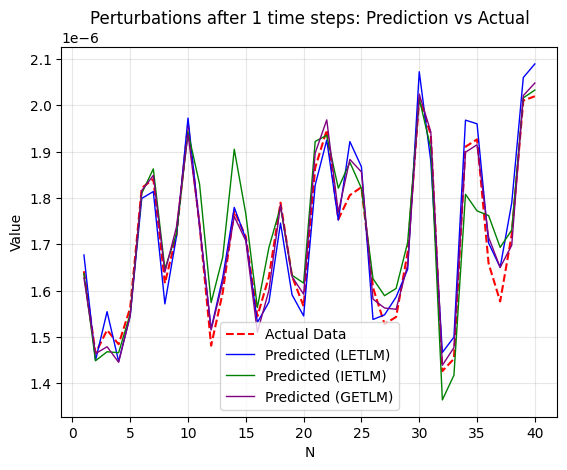

IETLM norm: tensor(0.1146)
LETLM norm: tensor(0.0365)
GETLM norm: tensor(0.0260)


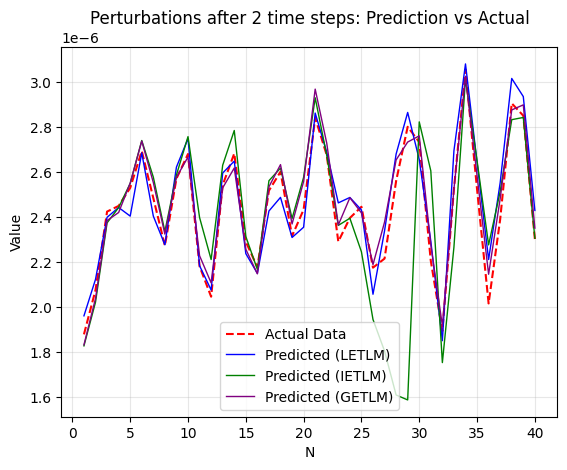

IETLM norm: tensor(0.1337)
LETLM norm: tensor(0.0537)
GETLM norm: tensor(0.0356)


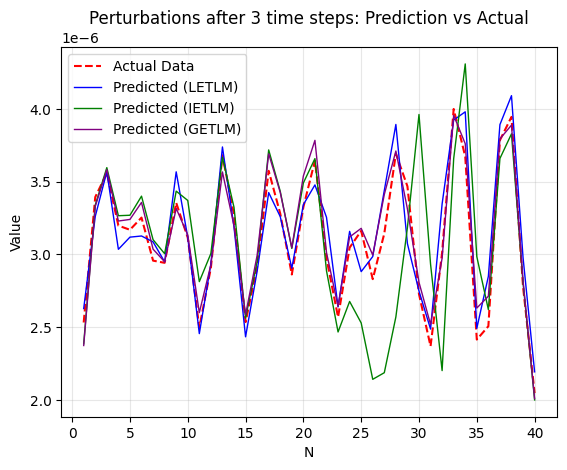

IETLM norm: tensor(0.1711)
LETLM norm: tensor(0.0991)
GETLM norm: tensor(0.0464)


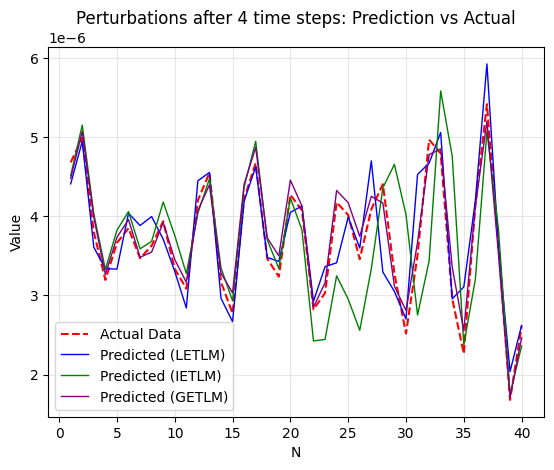

IETLM norm: tensor(0.2350)
LETLM norm: tensor(0.1775)
GETLM norm: tensor(0.0609)


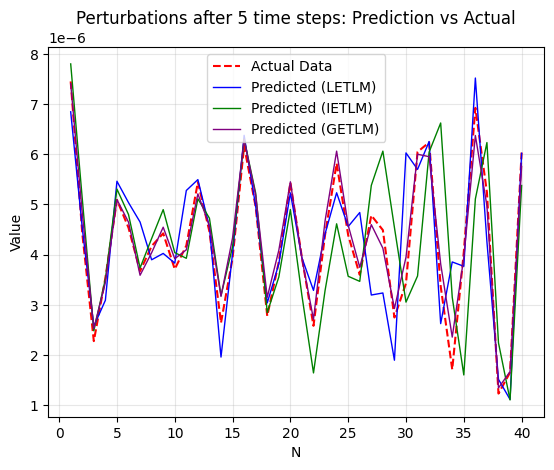

IETLM norm: tensor(0.3318)
LETLM norm: tensor(0.3023)
GETLM norm: tensor(0.0829)


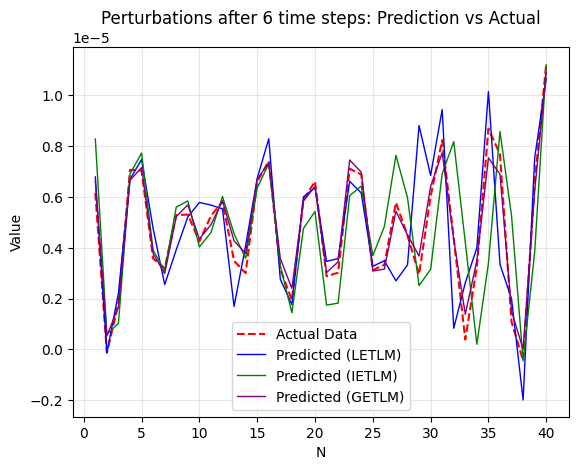

IETLM norm: tensor(0.4505)
LETLM norm: tensor(0.4560)
GETLM norm: tensor(0.1106)


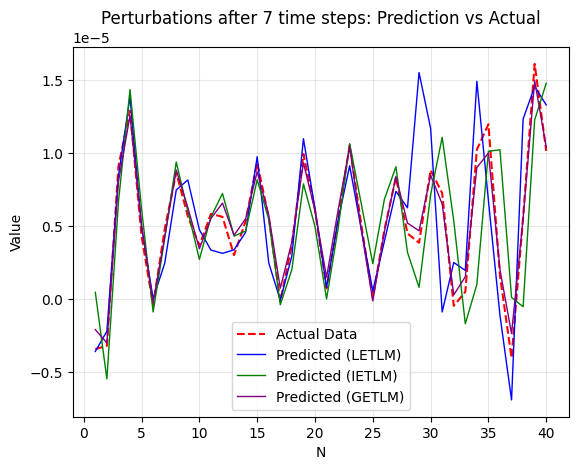

<Figure size 640x480 with 0 Axes>

In [30]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Perturbations after {i+1} time steps: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



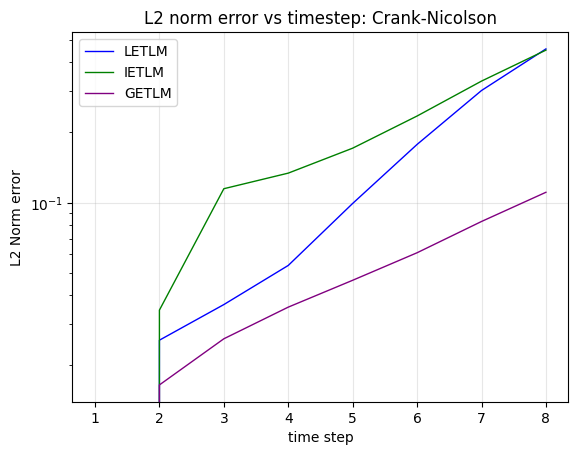

<Figure size 640x480 with 0 Axes>

In [31]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)

plt.title("L2 norm error vs timestep: Crank-Nicolson")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [ ]:
# We will also repeat this for Runge-Kutta 4

# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [ ]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

In [ ]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_RK4 = [-2,-1,0,1]
stencil_members_current_RK4 = [-2,-1,0,1]
stencil_members_past_RK4 = [-2,-1,0,1]
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_RK4 = 9 + len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final, Ensemble_final, Ensembles =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_RK4, SD_pert, model, model_parameters, Test_pert, number_of_steps = 20)


In [ ]:
IETLM_STENCIL_LARGE_RK4 = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_RK4 = [[0],[-6,-5,-4,-3,-2,-1,0,1,2,3,4,5]]

In [ ]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 2 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    LETLMS.append(M_tilde)


In [ ]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



In [ ]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)
plt.title("L2 norm error vs timestep: Runge-Kutta 4")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [ ]:
# We will also repeat this for Leapfrog
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [ ]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

In [ ]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_LF = [-2,-1,0,1]
stencil_members_current_LF = [-2,-1,0,1]
stencil_members_past_LF = [0]
stencil_members_large_LF = [stencil_members_future_LF, stencil_members_current_LF, stencil_members_past_LF]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_LF = 9 + len(stencil_members_future_LF) + len(stencil_members_current_LF) + len(stencil_members_past_LF)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final, Ensemble_final, Ensembles =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_LF, SD_pert, model, model_parameters, Test_pert, number_of_steps = 20)


In [ ]:
IETLM_STENCIL_LARGE_RK4 = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_RK4 = [[0],[-8,7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]

In [ ]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 1 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_LF, model_parameters, ensemble_size_LF, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_LF)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_LF)
    LETLMS.append(M_tilde)


In [ ]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Perturbations after {i+1} time steps: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



In [ ]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)
plt.title("L2 norm error vs timestep: Leapfrog")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()
